# Demonstration : Velocity Gradient
Calculation of traveltimes in a velocity gradient using an unstructured mesh

In [ ]:
# track time of process
import time

# for meshing 
import gmsh

# math
import numpy as np
#import os

# plotting mesh
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
#%matplotlib ipympl

# set default font size in plots
plt.rcParams.update({'font.size': 22})

# plotting violin plots 
import pandas as pd 
import seaborn as sns

## Importing local scripts and libraries into notebook


In [2]:
%reload_ext autoreload
%autoreload 2
import tritime2d as tt

## Input parameters

### Input parameters
**v1, v2** : velocity in first and second layer 
**vgrad_1, vgrad_2** : velocity gradient in frist and second layer

**z0_1 , z0_2** : start of velocity gradient 

Velocity Gradient in layer i is applied using the formula : v_i(z) = vi + vgrad_i*(z-z0_i) where z is taken as the centroid of the cell. To set a constant velocity to a layer set vgrad_i = 0

**sx**,**sz** : Source is automatically placed at origin.

**bx**,**bz** : width and depth of computational domain 

**layer_depth** : depth to layer 


**lcar** : mesh spacing at boundaries 

**scar** : mesh spacing at source

The source depth must be inside the computational area (i.e. 0 < sx < bx & 0 < sz < bz) as should the layer ( 0 < layer_depth < bz )

In [3]:
kilo = 1000;
v1 = 500;
v2 = 4500;

layer_depth = 10000.0
surf_dist = 1000.0 
z0_1 = 0. 
z0_2 = 0.

vgrad_1 = (v2-v1)/(layer_depth-z0_1)  
print('velocity gradient',vgrad_1)
vgrad_2 = 0.

sx = 0.0    # do not change
sz = 0.0    # do not change 


bx = 20*kilo 
bz = 10*kilo 

scar = 20.0 #10.0
tcar = 20.0 #20 #scar # 50. # 50.0
bcar = 400.0

print('cell size gradient',(bcar-scar)/(bz-sz))

nlayers = 1
v = v1 #[v1, v2];
vgrad = vgrad_1 #[vgrad_1 ,  vgrad_2]
Grad_z0 = [z0_1 , z0_2]


velocity gradient 0.4
cell size gradient 0.038


## Create Mesh using GMSH

In [4]:
gmsh.initialize()

gmsh.model.add("Gradient Model")

## This mesh increases linearly with depth

In [ ]:
gmsh.clear()

# All points use a nominal size (overridden by the field)
s1 = gmsh.model.geo.addPoint(sx, sz, 0, scar, 1)
p3 = gmsh.model.geo.addPoint(bx,  0,  0, tcar, 3)
p5 = gmsh.model.geo.addPoint(bx, bz,  0, bcar, 5)
p6 = gmsh.model.geo.addPoint(0.0, bz, 0, bcar, 6)

l13 = gmsh.model.geo.addLine(s1, p3, 23)
gmsh.model.geo.addLine(p3, p5, 35)
gmsh.model.geo.addLine(p5, p6, 56)
gmsh.model.geo.addLine(p6, s1, 61)

gmsh.model.geo.addCurveLoop([l13, 35, 56, 61], 1)
gmsh.model.geo.addPlaneSurface([1], 1)
gmsh.model.geo.synchronize()

# Linear size increase with depth: scar at y=0, bcar at y=bz
depth_f = gmsh.model.mesh.field.add("MathEval")
gmsh.model.mesh.field.setString(depth_f, "F", f"{scar} + ({bcar} - {scar}) * y / {bz}")

gmsh.model.mesh.field.setAsBackgroundMesh(depth_f)

gmsh.model.addPhysicalGroup(2, [1], 1)
gmsh.option.setNumber("Mesh.Algorithm", 5)
gmsh.option.setNumber("Mesh.RandomFactor", 1e-9)
gmsh.option.setNumber("Mesh.Smoothing", 100)
gmsh.model.mesh.generate(2)

#gmsh.write("test.vtk")
# Clear existing model
# gmsh.finalize()   # doing this will mean that you lose the mesh

Info    : Clearing all models and views...
Info    : Done clearing all models and views
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 23 (Line)
Info    : [ 30%] Meshing curve 35 (Line)
Info    : [ 60%] Meshing curve 56 (Line)
Info    : [ 80%] Meshing curve 61 (Line)
Info    : Done meshing 1D (Wall 0.00640384s, CPU 0.006959s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Delaunay)
Info    : Done meshing 2D (Wall 28.3011s, CPU 28.2939s)
Info    : 33991 nodes 67984 elements


### Extract the Nodes and Elements from the mesh

In [6]:
x, y, z, cells, cell_type = tt.extract_mesh()

In [7]:
cell_vel = tt.velocity_gradient(cells, y, v1, vgrad)


## Compute analytical solution 
The travel time in a gradient field given as $ v(z) = a+ b\, z $ is (Slotnick, M. M., 1959, Lessons in Seismic Computing: Soc. of Expl. Geophys.) :

$t(x,z) = \frac{1}{b} \cosh^{-1} \Big( 1+ \frac{(b\, z)^2+ (b\, x)^2} {2\, a \,(b\, z +a)} \Big) $

Time is calculated on the same nodes as the time. 

In [8]:
theo_time = 1./vgrad*np.arccosh( 1 + ((vgrad*y)**2+(vgrad*x)**2)/(2.*v1*(vgrad*y+v1)) )


### Assign initial travel time 

In [12]:
initial_time = tt.init_traveltime(sx, sz, x, y, cells, cell_vel)


Source location [0.0, 0.0], source is in cell 4205
Initial travel time on starting cell: [0.         0.03980388 0.05237163]
Source located at a single node


### Set diffraction points 
No diffraction points used

In [15]:
diff_nodes = np.zeros(len(x))


### Plot input model and analytical solution  
We plot the mesh, the defined diffraction points and source location. Contours of the analytical solution are plotted as contours

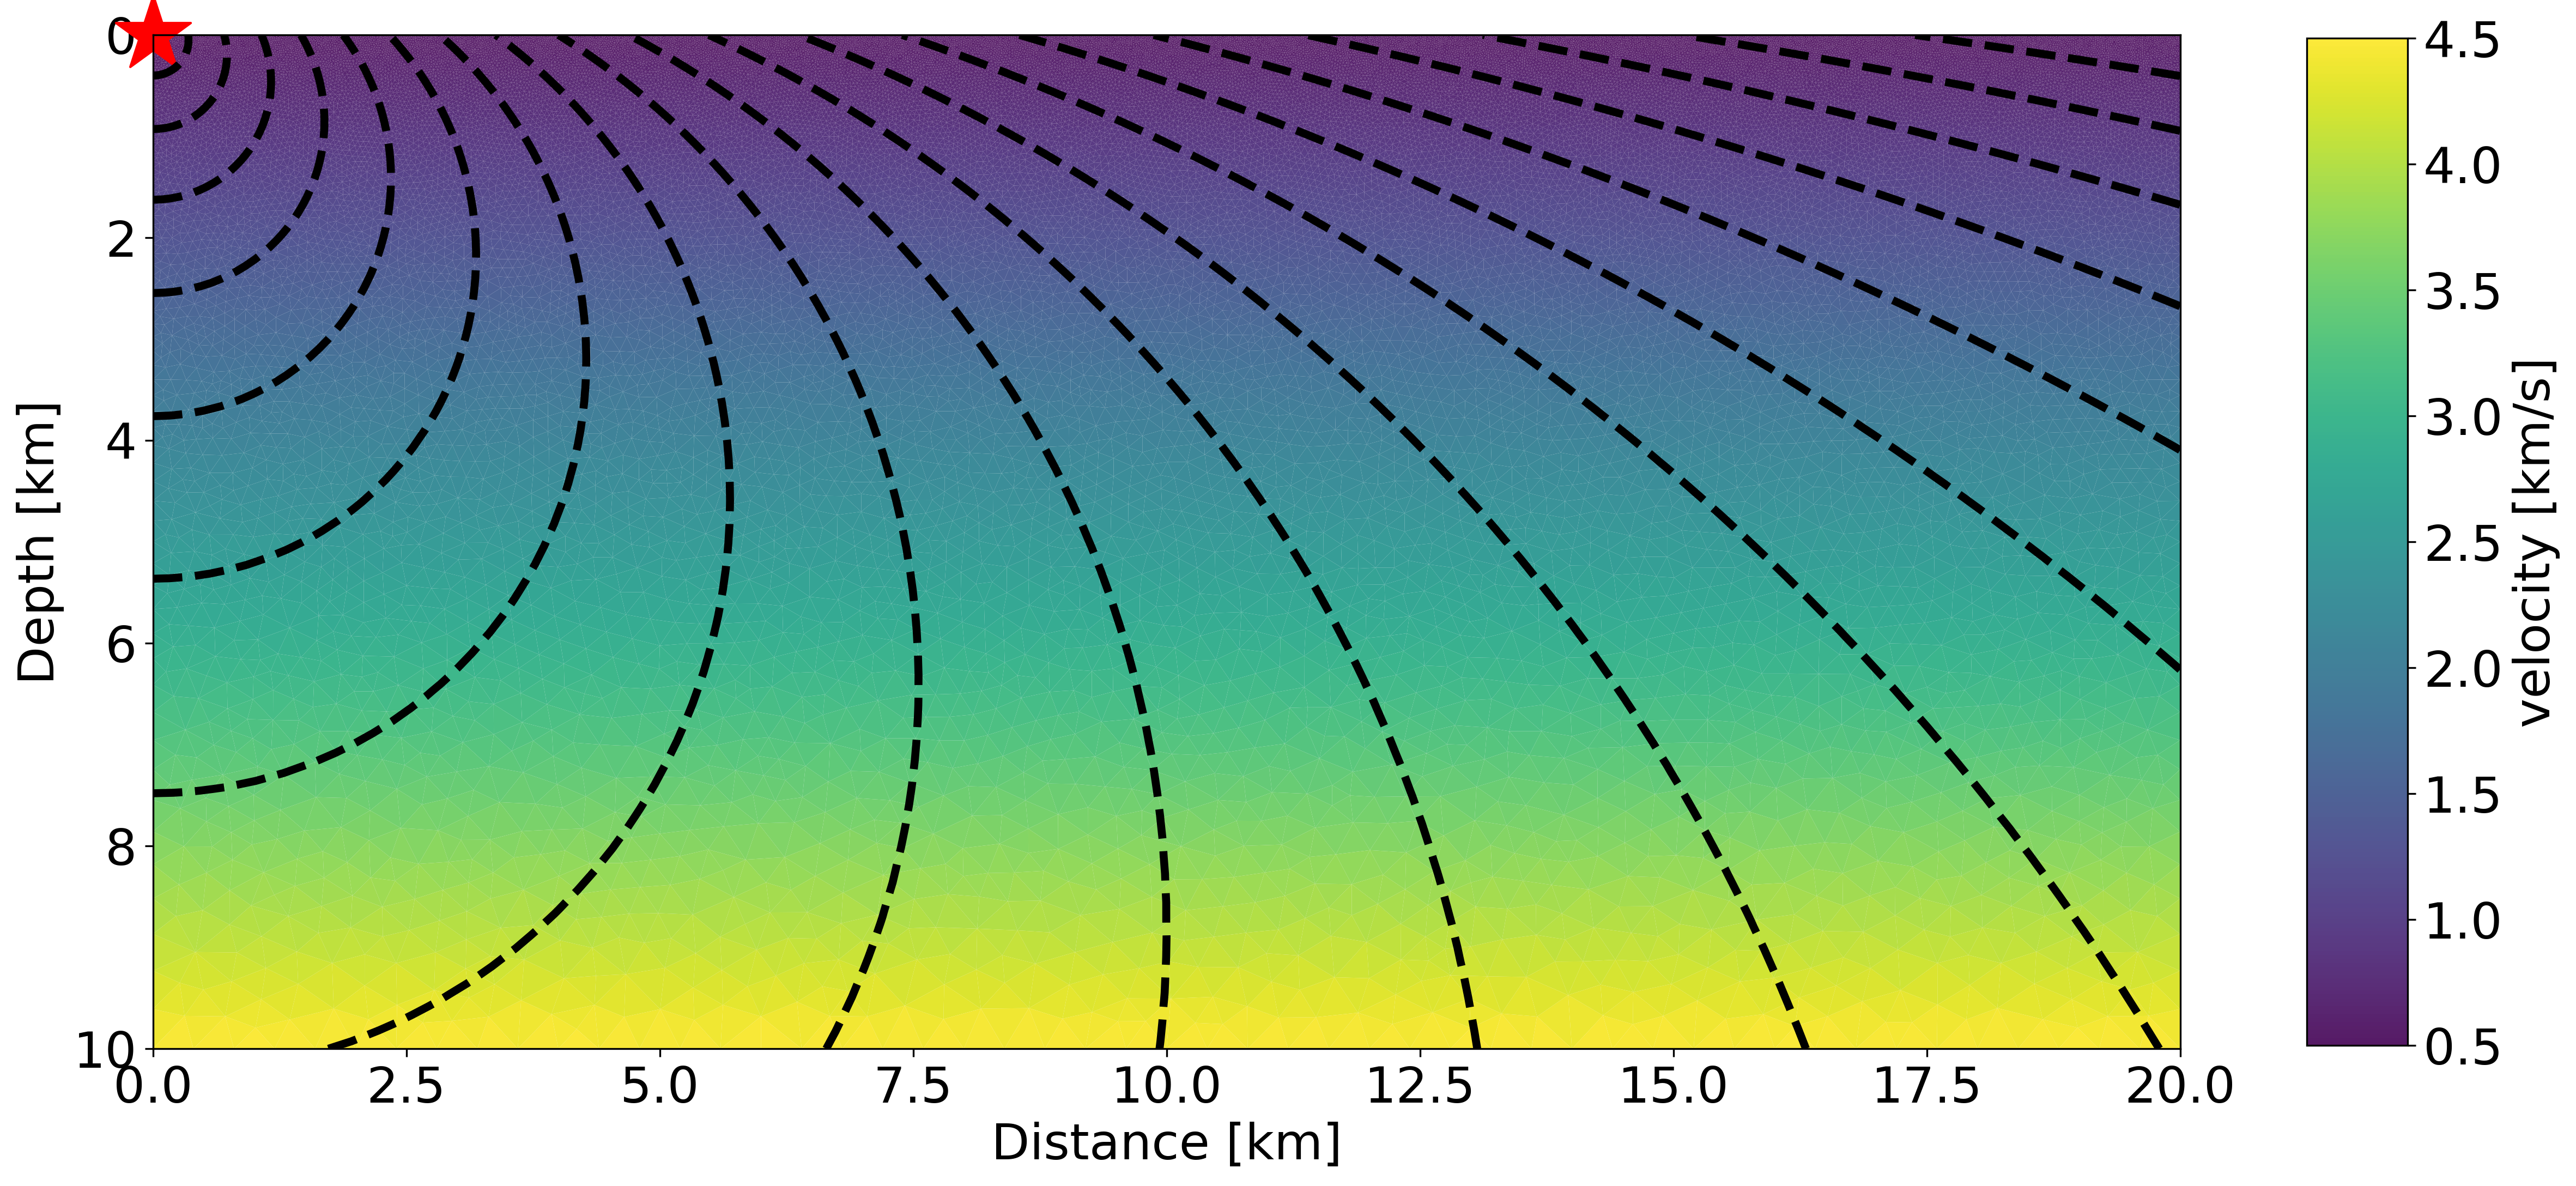

In [16]:
kilo = 1000 

patches = []
for i in range(len(cells)):
    idx = cells[i]
    poly_pts = np.transpose(np.vstack((x[idx]/kilo,y[idx]/kilo)))
    polygon = Polygon(poly_pts)
    patches.append(polygon)


fig, ax = plt.subplots(figsize=(20,20), dpi=300)  
p = PatchCollection(patches, alpha=0.9,edgecolor='none', cmap='viridis')
p.set_array(cell_vel/kilo)
p.set_clim(vmin=0.5, vmax=4.5)  # Set your desired min/max values here

ax.add_collection(p)
plt.scatter(sx/kilo, sz/kilo, c='red', s=1200, marker='*', label='Source',zorder=2, clip_on=False)

max_time = max(theo_time)
min_time = min(theo_time)
ncontours = 20
dc = (max_time-min_time)/ncontours
levels = np.arange(min_time, max_time+dc,dc )

# plot figure 
tcf_tri = plt.tricontour(x/kilo, y/kilo, theo_time,levels = levels, colors='k',linestyles='--',linewidths=3.5)

mask = diff_nodes > 0
if mask.any():
    plt.scatter(x[mask]/kilo, y[mask]/kilo, s=250, c='r', marker='.', zorder=5, label='Diffraction nodes')

cbar = fig.colorbar(p, ax=ax,shrink=0.4, aspect=10, pad=0.05)
cbar.set_label('velocity [km/s]',fontsize=22)

plt.xlim(np.min(x/kilo),np.max(x/kilo)) 
plt.ylim(np.max(y/kilo),np.min(y/kilo)) # flip axis for depth
ax.set_aspect('equal')

ax.set_xlabel(r'Distance [km]',fontsize=22)
ax.set_ylabel(r'Depth [km]',fontsize=22)

plt.show()

In [17]:
print('In TriTime2d, no. of cells:', len(cell_vel), ' no. of nodes:', len(x))

In TriTime2d, no. of cells: 66772  no. of nodes: 33991


## Run TriTime2d

In [19]:
start=time.time()
traveltime = tt.tritime2d(x, y, z, cells, cell_vel, initial_time, diff_nodes, fast=True)
end=time.time()
print(end-start)


 starting trilateration.....
0.15865802764892578


## Calculate error in traveltimes

In [ ]:
mask = theo_time > 0.
safe_time = np.where(mask, theo_time, 1.)  # replace 0s with 1 to avoid divide-by-zero
Tri_Theo_diff = np.where(mask, (traveltime - theo_time) / safe_time * 100, 0.)

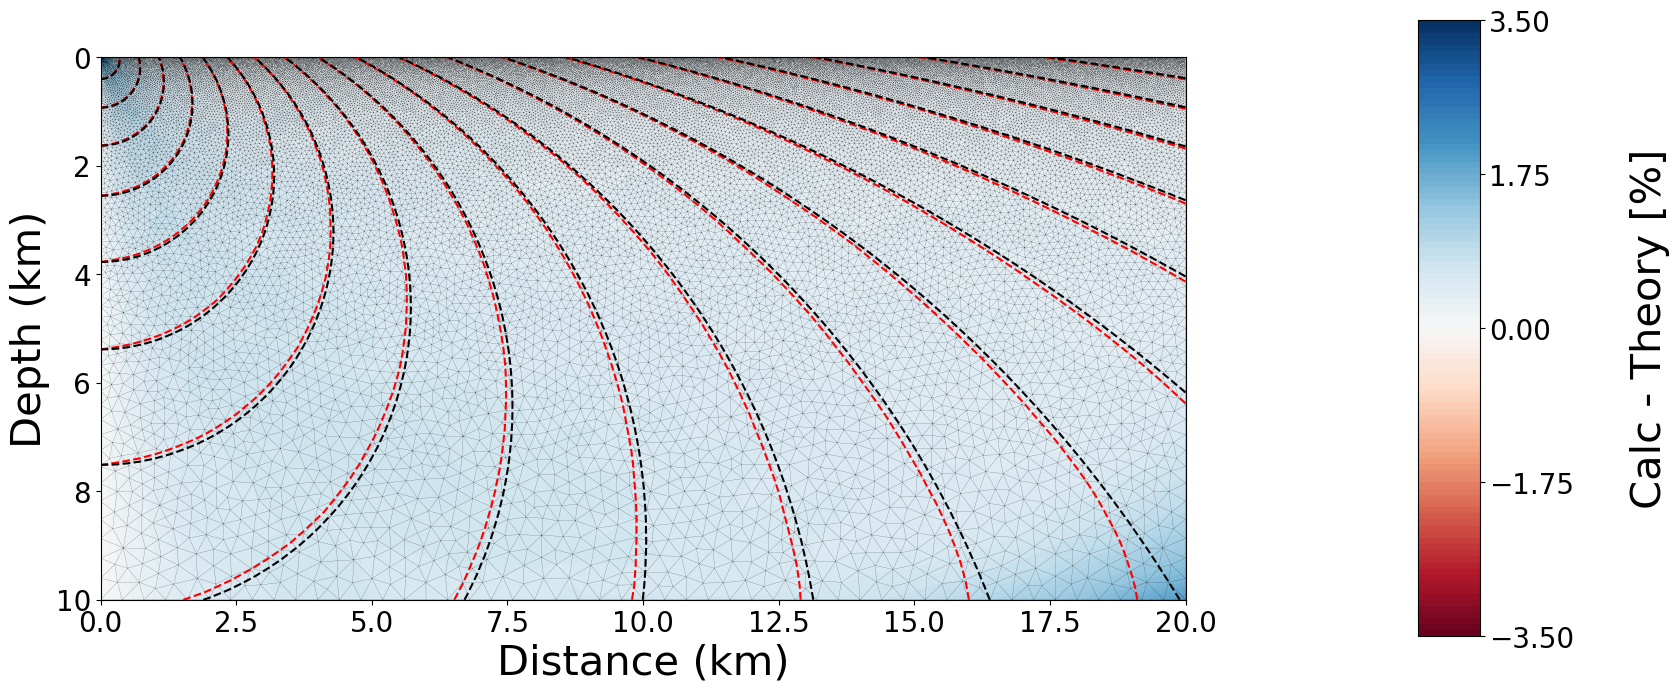

In [21]:
# c_range = np.max(np.max((abs(np.max(Tri_Theo_diff)),abs(np.min(Tri_Theo_diff)))))
c_range = 3.5

dcc = (2*c_range)/100
clevels=np.arange(-c_range,c_range+dcc,dcc )

max_time = max(traveltime)
min_time = min(traveltime)
ncontours = 20
dc = (max_time-min_time)/ncontours
levels = np.arange(min_time, max_time+dc,dc )


# plot figure 
fig = plt.figure(figsize=(20,20))
ax1 = plt.axes()
ax1.set_aspect('equal')

plt.triplot(x/kilo, y/kilo, cells, color='black', linewidth=0.1, zorder=2)
tcf_tri  = plt.tricontour( x/kilo, y/kilo, traveltime, levels=levels, colors='r', linestyles='--', zorder=2)
tcf_theo = plt.tricontour( x/kilo, y/kilo, theo_time,  levels=levels, colors='k', linestyles='--', zorder=2)
cc       = plt.tricontourf(x/kilo, y/kilo, Tri_Theo_diff, clevels, cmap='RdBu', zorder=1)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Distance (km)',fontsize=30)
plt.ylabel('Depth (km)',fontsize=30)

# Color bar
tt = np.linspace(-c_range, c_range, 5, endpoint=True)
cb=plt.colorbar(cc,shrink=0.4, aspect=10, pad=0.15,ticks=tt)
cb.ax.tick_params(axis='both', which='major', labelsize=20)
cb.set_label('Calc - Theory [%]', fontsize=30, rotation=90, labelpad=40)
ax1.invert_yaxis()


# fig.tight_layout()
plt.show()


Plot error along surface

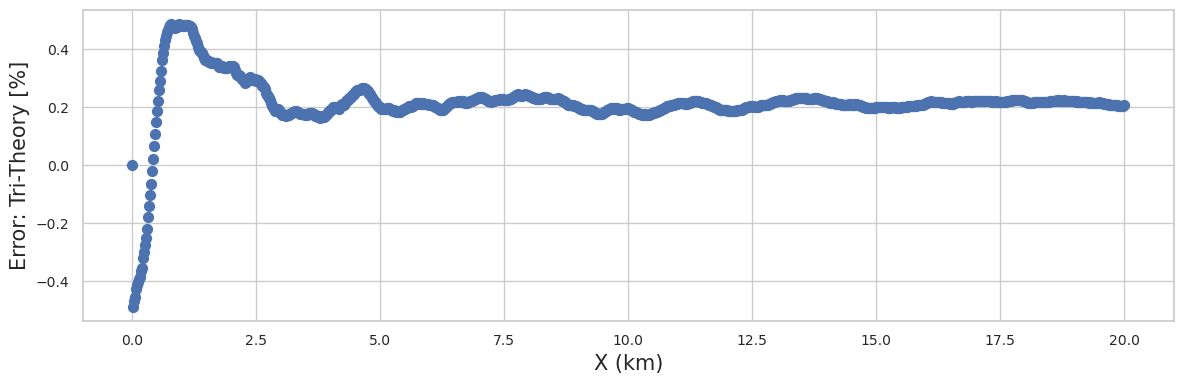

In [26]:

# take the point that are only on the surface 
surf_id = np.where(y <= 0.001)

fig = plt.figure(figsize=(12,4))
plt.scatter(x[surf_id]/kilo, Tri_Theo_diff[surf_id], s=50)
plt.xlabel('X (km)',fontsize=15)
plt.ylabel('Error: Tri-Theory [%]',fontsize=15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True)
fig.tight_layout()
plt.show()

Plot error distribution

In [22]:
print('error range:    ',np.max(Tri_Theo_diff),np.min(Tri_Theo_diff) ,'%')

error range:     4.609950141538314 -0.48924373322377157 %


In [23]:

# Create categories
categories = (['TriTime'] * len(Tri_Theo_diff))

# Combine the data
values = np.concatenate([Tri_Theo_diff])

# Create the DataFrame
df = pd.DataFrame({'Solver': categories, 'Error': values})

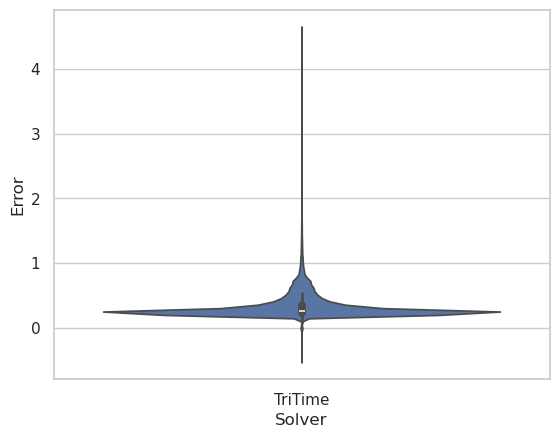

In [24]:
sns.set_theme(style="whitegrid")
ax = sns.violinplot(x="Solver", y="Error",data=df, hue="Solver",legend=False)

Write out results in a vtk file that can be read by paraview

In [ ]:
write_vtk(x, y, z, cells, cell_vel, traveltime, "Velocity_Gradient_Case.vtk")